# Local one-day smooth=0.5 nugget=1 mismatch run

This notebook runs the same smoothness/nugget mismatch driver locally, using subprocesses so fit and conditional-eigen diagnostics are separated by process exit.

Important: the target DGP for this notebook is Matern smooth=0.5, nugget=1. The notebook validates the truth JSON before running, then runs two comparisons: fixed smooth=0.5 with nugget 0/1/2, and fixed nugget=1 with smooth 0.3/0.5/1.0.

In [1]:
from pathlib import Path
import json
import os
import shlex
import subprocess
import sys
import time

ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
EIG_DIR = ROOT / 'Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis'
SCRIPT = EIG_DIR / 'vecchia_conditional_eigen_sort_sim_smooth0p5_nugget_mismatch_070926.py'
assert SCRIPT.exists(), SCRIPT

print('python:', sys.executable)
print('repo:', ROOT)
print('driver:', SCRIPT)

try:
    import torch
    print('torch:', torch.__version__)
    print('cuda available:', torch.cuda.is_available())
except Exception as exc:
    print('Torch import failed in this kernel:', repr(exc))
    print('Switch the notebook kernel to the environment that has torch/GEMS_TCO, e.g. faiss_env.')


python: /opt/anaconda3/envs/faiss_env/bin/python
repo: /Users/joonwonlee/Documents/GEMS_TCO-1
driver: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis/vecchia_conditional_eigen_sort_sim_smooth0p5_nugget_mismatch_070926.py
torch: 2.5.1
cuda available: False


## Locate smooth=0.5 nugget=1 data

The existing local `july_st_circulant_realpattern_smooth0p5` folder is expected to have `--nugget 1.0`. This notebook reuses it only if its truth JSON says `smooth == 0.5` and `nugget == 1`.

In [2]:
SIM_BASE = Path('/Users/joonwonlee/Documents/GEMS_DATA/simulation')
YEAR = 2023
SIM_KIND = 'gridded'

TRUTH_NUGGET = 1.0
DATA_CANDIDATES = [
    SIM_BASE / 'july_st_circulant_realpattern_smooth0p5',
    SIM_BASE / 'july_st_circulant_realpattern_smooth0p5_nugget1',
    SIM_BASE / 'july_st_circulant_realpattern_smooth0p5_nugget1_oneday_070926',
]

def truth_path(root, year=YEAR):
    return root / f'{year}_july_st_circulant' / f'sim_july{year}_st_circulant_truth.json'

def pkl_path(root, year=YEAR, kind=SIM_KIND):
    return root / f'{year}_july_st_circulant' / f'sim_july{year}_st_circulant_{kind}.pkl'

def read_truth(root):
    path = truth_path(root)
    if not path.exists():
        return None
    return json.loads(path.read_text())

def valid_s05_n1(root):
    truth = read_truth(root)
    if truth is None or not pkl_path(root).exists():
        return False
    return abs(float(truth.get('smooth', float('nan'))) - 0.5) < 1e-12 and abs(float(truth.get('nugget', float('nan'))) - TRUTH_NUGGET) < 1e-12

for root in DATA_CANDIDATES:
    truth = read_truth(root)
    print('\nroot:', root)
    print('  exists:', root.exists())
    print('  pkl:', pkl_path(root).exists(), pkl_path(root))
    if truth is None:
        print('  truth: missing')
    else:
        print('  truth smooth:', truth.get('smooth'), 'nugget:', truth.get('nugget'), 'n_hours:', truth.get('n_hours'))

valid_roots = [root for root in DATA_CANDIDATES if valid_s05_n1(root)]
DATA_ROOT = valid_roots[0] if valid_roots else DATA_CANDIDATES[0]
GENERATE_IF_MISSING = False

print('\nselected DATA_ROOT:', DATA_ROOT)
if not valid_roots:
    print('No validated local smooth=0.5 nugget=1 root was found.')
    print('If the nugget1 data lives elsewhere, set DATA_ROOT manually in the next cell.')
    print('If you want to generate a new one-day nugget1 asset, set GENERATE_IF_MISSING=True.')



root: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5
  exists: True
  pkl: True /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2023_july_st_circulant/sim_july2023_st_circulant_gridded.pkl
  truth smooth: 0.5 nugget: 1.0 n_hours: 248

root: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5_nugget1
  exists: False
  pkl: False /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5_nugget1/2023_july_st_circulant/sim_july2023_st_circulant_gridded.pkl
  truth: missing

root: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5_nugget1_oneday_070926
  exists: False
  pkl: False /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5_nugget1_oneday_070926/2023_july_st_circulant/sim_july2023_st_circulant_gridded.pkl
  truth: missing

selected DATA_ROOT: /Users/joonwonlee

## Run configuration

Start with `DOMAIN_MODE='small'` for local sanity checks. Set `DOMAIN_MODE='full'` only when you want the full `lat=-3..2`, `lon=121..131` domain.

In [3]:
# If nugget1 data is somewhere else, override DATA_ROOT here.
# DATA_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA/simulation/your_smooth0p5_nugget1_root')
# GENERATE_IF_MISSING = True  # creates one-day nugget1 data at DATA_ROOT if missing

DOMAIN_MODE = 'small'  # 'tiny', 'small', 'medium', or 'full'
DOMAIN_BOX = {
    'tiny': ('-0.5,0.5', '124,126'),
    'small': ('-1,1', '123.5,127.5'),
    'medium': ('-2,1', '123,129'),
    'full': ('-3,2', '121,131'),
}
LAT_RANGE, LON_RANGE = DOMAIN_BOX[DOMAIN_MODE]

EXPERIMENT = 'both_dgp1'  # smoothness_mismatch_dgp1 + nugget_mismatch_dgp1
DAY_SPEC = '0'
DEVICE = 'cpu'
TARGET_CHUNK_SIZE = 4     # local-safe; increase to 8/16 if memory is fine
DIAG_CHUNK_SIZE = 16      # local-safe diagnostic chunk
LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HISTORY = 10
SPLINE_N_POINTS = 4000
RESAMPLE_GRID = 200

OUT_ROOT = ROOT / 'outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print('DATA_ROOT:', DATA_ROOT)
print('OUT_ROOT:', OUT_ROOT)
print('DOMAIN_MODE:', DOMAIN_MODE, 'lat:', LAT_RANGE, 'lon:', LON_RANGE)
print('GENERATE_IF_MISSING:', GENERATE_IF_MISSING)


DATA_ROOT: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5
OUT_ROOT: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926
DOMAIN_MODE: small lat: -1,1 lon: 123.5,127.5
GENERATE_IF_MISSING: False


In [4]:
if not GENERATE_IF_MISSING and not valid_s05_n1(DATA_ROOT):
    truth = read_truth(DATA_ROOT)
    raise RuntimeError(
        f'DATA_ROOT is not validated smooth=0.5 nugget=1: {DATA_ROOT}\n'
        f'truth={truth}\n'
        'Set DATA_ROOT to the nugget1 folder, or set GENERATE_IF_MISSING=True.'
    )

cmd = [
    sys.executable,
    str(SCRIPT),
    '--experiment', EXPERIMENT,
    '--isolate-models',
    '--split-fit-diagnostic',
    '--data-root', str(DATA_ROOT),
    '--out-root', str(OUT_ROOT),
    '--years', str(YEAR),
    '--month', '7',
    '--days', DAY_SPEC,
    '--hours-per-day', '8',
    '--truth-nugget', str(TRUTH_NUGGET),
    '--sim-kind', SIM_KIND,
    f'--lat-range={LAT_RANGE}',
    f'--lon-range={LON_RANGE}',
    '--keep-exact-loc',
    '--real-reference-advec-lon-abs', '0.126',
    '--daily-stride', '2',
    '--target-chunk-size', str(TARGET_CHUNK_SIZE),
    '--diag-chunk-size', str(DIAG_CHUNK_SIZE),
    '--min-target-points', '1',
    '--spline-n-points', str(SPLINE_N_POINTS),
    '--spline-r-max', '30.0',
    '--lbfgs-lr', '1.0',
    '--lbfgs-steps', str(LBFGS_STEPS),
    '--lbfgs-eval', str(LBFGS_EVAL),
    '--lbfgs-history', str(LBFGS_HISTORY),
    '--grad-tol', '1e-5',
    '--device', DEVICE,
    '--cuda-fallback', 'cpu',
    '--resample-grid', str(RESAMPLE_GRID),
    '--suppress-fit-prints',
]
if GENERATE_IF_MISSING:
    cmd.append('--generate-if-missing')

print('Command:')
print(' '.join(shlex.quote(x) for x in cmd))


Command:
/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis/vecchia_conditional_eigen_sort_sim_smooth0p5_nugget_mismatch_070926.py --experiment both_dgp1 --isolate-models --split-fit-diagnostic --data-root /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5 --out-root /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926 --years 2023 --month 7 --days 0 --hours-per-day 8 --truth-nugget 1.0 --sim-kind gridded --lat-range=-1,1 --lon-range=123.5,127.5 --keep-exact-loc --real-reference-advec-lon-abs 0.126 --daily-stride 2 --target-chunk-size 4 --diag-chunk-size 16 --min-target-points 1 --spline-n-points 4000 --spline-r-max 30.0 --lbfgs-lr 1.0 --lbfgs-steps 5 --lbfgs-eval 20 --lbfgs-history 10 --grad-tol 1e-5 --device cpu --cuda-fallback cpu --resample-grid 200 --suppress-f

In [5]:
t0 = time.time()
subprocess.run(cmd, cwd=str(EIG_DIR), check=True)
print(f'Finished in {(time.time() - t0) / 60:.1f} minutes')


Reusing validated smooth=0.5 nugget=1 simulation data: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5

####################################################################################################
Running smoothness_mismatch_dgp1 with separate fit-only and diag-only Python processes per model: variants=['matern_s05_n1_true', 'matern_s03_n1_rough', 'matern_s10_n1_smooth']
Output: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926/smoothness_mismatch_dgp1
####################################################################################################

----------------------------------------------------------------------------------------------------
Worker start: smoothness_mismatch_dgp1/matern_s05_n1_true/fit
/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/eige

## Inspect summaries and plots

summary csv files:
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926/nugget_mismatch_dgp1/sim_july_st_s05_n0_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926_nugget_mismatch_dgp1_matern_s05_n0_under_summary.csv
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926/nugget_mismatch_dgp1/sim_july_st_s05_n0_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926_nugget_mismatch_dgp1_matern_s05_n1_true_summary.csv
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926/nugget_mismatch_dgp1/sim_july_st_s05_n0_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926_nugget_mismatch_dgp1_matern_s05_n2_over_summary.csv
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_ve

,status,error,year,month,day_idx,day,model_variant,model_family,model_label,smooth,...,local_rank12_n,local_rank13_mean_y2,local_rank13_n,local_rank14_mean_y2,local_rank14_n,local_rank15_mean_y2,local_rank15_n,local_rank16_mean_y2,local_rank16_n,diag_s
0,ok,NaN,2023,7,0,2023-07-01,matern_s05_n0_under,matern,Matern s=0.5 nugget0 under,0.5,...,1392,1.124045,1356,1.141844,1326,1.182858,1307,1.298578,1272,0.453104
1,ok,NaN,2023,7,0,2023-07-01,matern_s05_n1_true,matern,Matern s=0.5 nugget1 true,0.5,...,1392,1.021380,1356,0.986435,1326,1.032357,1307,1.070600,1272,0.463455
2,ok,NaN,2023,7,0,2023-07-01,matern_s05_n2_over,matern,Matern s=0.5 nugget2 over,0.5,...,1392,0.812286,1356,0.762624,1326,0.797740,1307,0.803277,1272,0.459529



=== sim_july_st_s05_n0_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926_smoothness_mismatch_dgp1_summary.csv ===


,status,error,year,month,day_idx,day,model_variant,model_family,model_label,smooth,...,local_rank12_n,local_rank13_mean_y2,local_rank13_n,local_rank14_mean_y2,local_rank14_n,local_rank15_mean_y2,local_rank15_n,local_rank16_mean_y2,local_rank16_n,diag_s
0,ok,NaN,2023,7,0,2023-07-01,matern_s05_n1_true,matern,Matern s=0.5 nugget1 true,0.5,...,1392,1.021380,1356,0.986435,1326,1.032357,1307,1.070600,1272,0.484158
1,ok,NaN,2023,7,0,2023-07-01,matern_s03_n1_rough,matern,Matern s=0.3 nugget1 rough,0.3,...,1392,0.869525,1356,0.824625,1326,0.864061,1307,0.878770,1272,0.882414
2,ok,NaN,2023,7,0,2023-07-01,matern_s10_n1_smooth,matern,Matern s=1.0 nugget1 smooth,1.0,...,1392,1.186824,1356,1.191842,1326,1.236058,1307,1.330228,1272,0.874827



plots:
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926/nugget_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


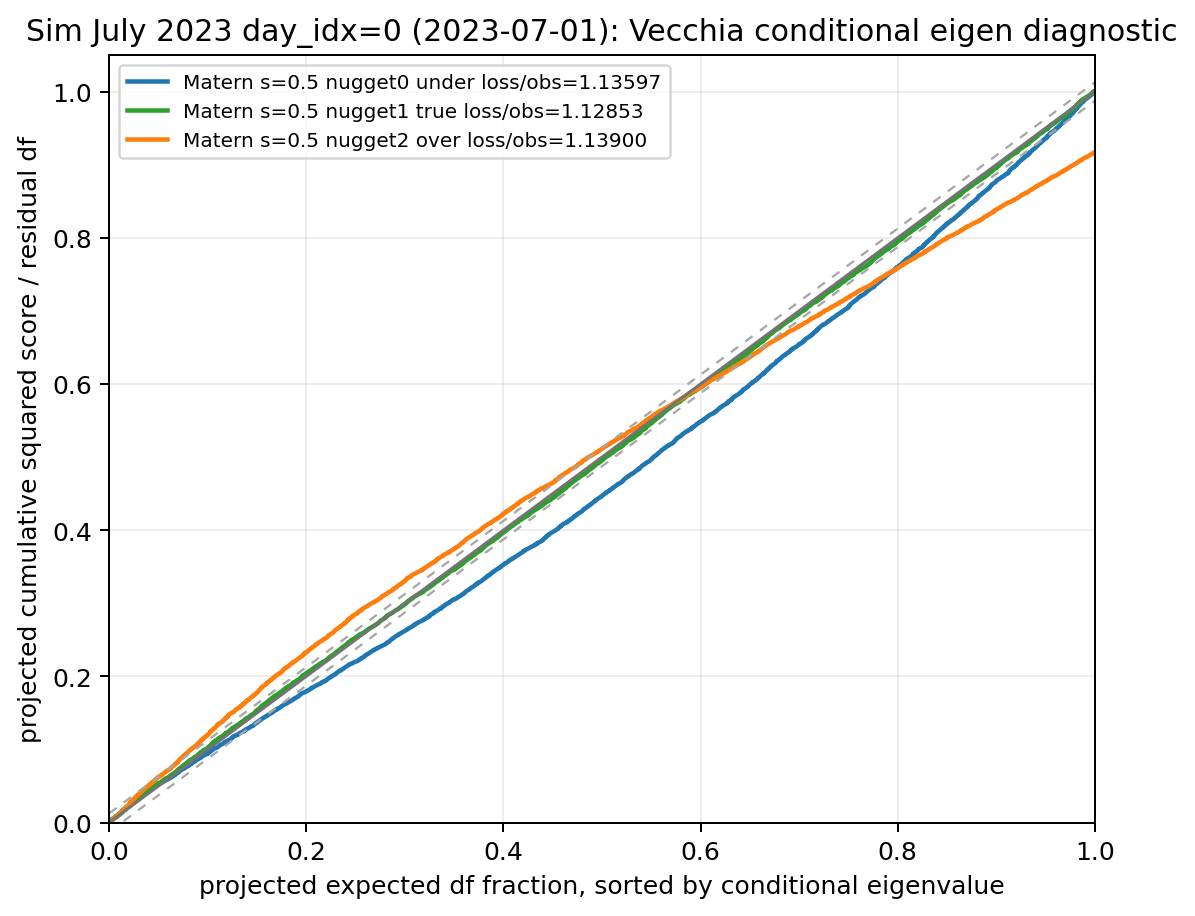

  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_july_st_s05_n1_vecchia_conditional_eigen_sort_smooth_nugget_mismatch_070926/smoothness_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


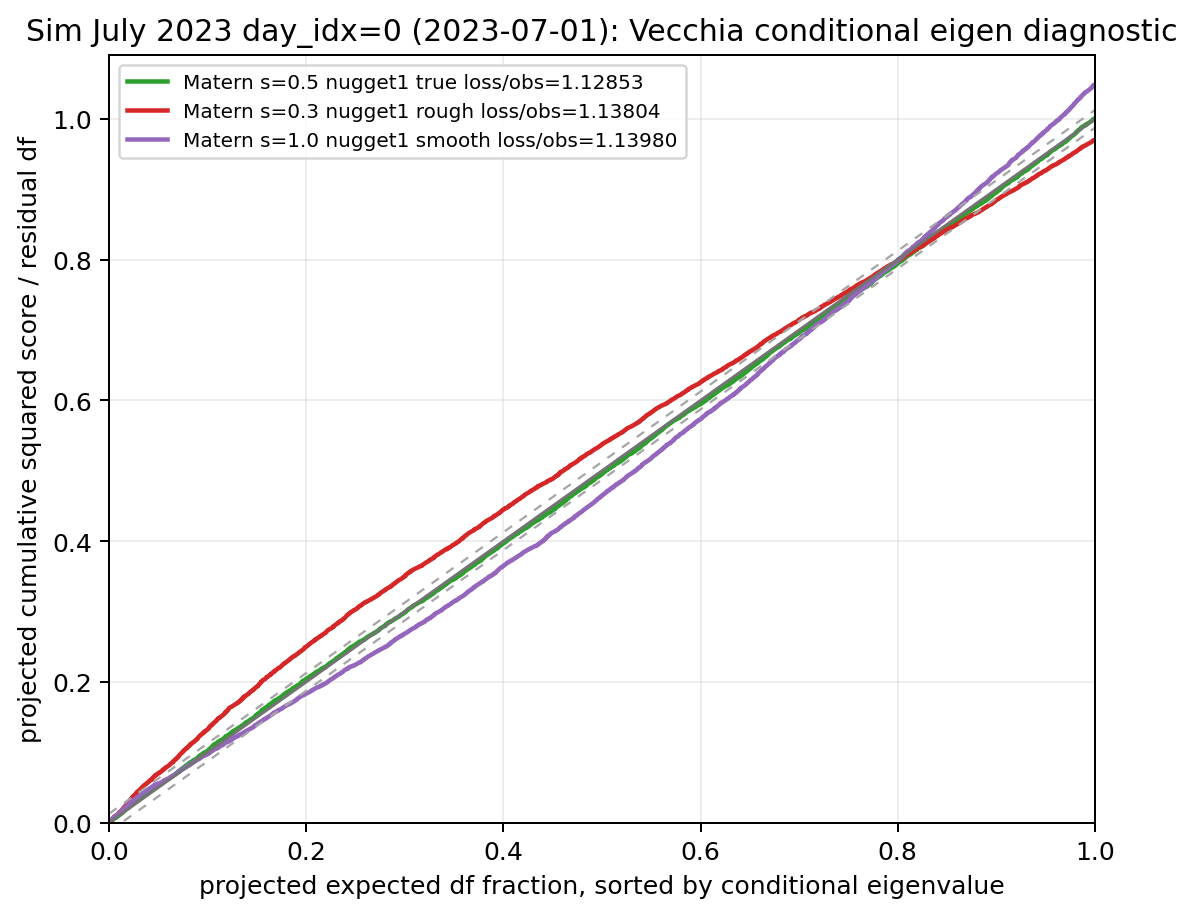

In [6]:
import pandas as pd
from IPython.display import Image, display

summary_paths = sorted(OUT_ROOT.glob('**/*_summary.csv'))
print('summary csv files:')
for path in summary_paths:
    print(' ', path)

combined = [
    p for p in summary_paths
    if p.name.endswith('_smoothness_mismatch_dgp1_summary.csv') or p.name.endswith('_nugget_mismatch_dgp1_summary.csv')
]
for path in combined:
    print('\n===', path.name, '===')
    display(pd.read_csv(path))

plot_paths = sorted(OUT_ROOT.glob('**/daily_plots/**/*.png'))
print('\nplots:')
for path in plot_paths:
    print(' ', path)
    display(Image(filename=str(path)))
